# MATH 630 Modeling Project 2 Simulations

Let $P_1, P_2$ be populations (of humans, bats, birds, etc. I guess.) Each member of the population belongs to one of two categories: $\{\text{sick}, \text{healthy}\} \cong \{1, 0\}$. Suppose $P_1$ and $P_2$ are governed by the following rules, respectively:

## Rules for Population 1
Each day (beginning with Day 0), every healthy individual uniformly selects a member of the population (and this can be self-referential), and shakes their hand. (If this is a non-human population, they now have hands.) If the targeted person is sick, then the healthy person becomes sick the next day.

## Rules for Population 2
Each day (beginning with Day 0), every sick individual uniformly selects a member of the population (and this can be self-referential), and shakes their hand. (If this is a non-human population, they now have hands.) If the targeted person is healthy, then this healthy person becomes sick the next day.


Text(0, 0.5, 'Population of sick people')

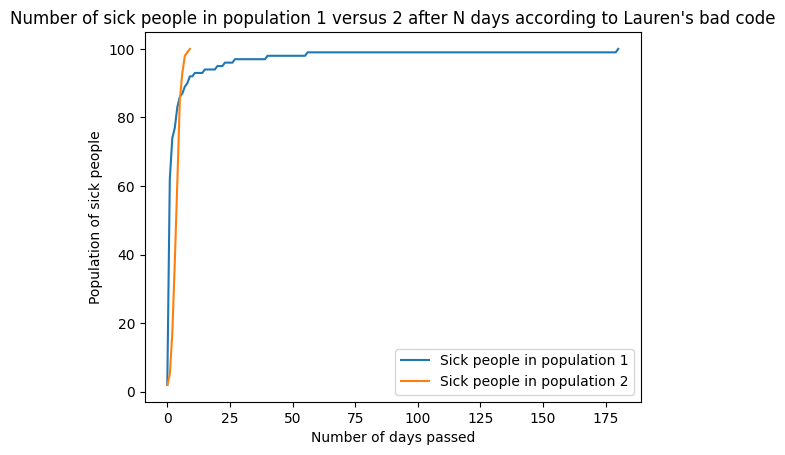

In [15]:
import numpy as np
import matplotlib.pyplot as plt

'''
Simulation.ipynb

Discrete-event interpretation of Population 1 & 2 infection rules. A lot of it IS redundant with a few tweaks so
I could just generalize it if I wanted to...
TODO it would be way easier to bookkeep in the literal sense if I just kept track of sick, healthy people
in a Python dictionary
'''
# at each time step (day), these will keep track of the numbers
c_1_num_healthy = []
c_1_num_sick = []
c_1_num_iters = []

c_2_num_healthy = []
c_2_num_sick = []
c_2_num_iters = []

class population1:
  '''
  Rule: every HEALTHY person selects a person out of the population uniformly at random.
  If that person is sick, then the healthy person becomes sick the next day.
  '''
  def __init__(self, num_people, initial_num_infected):
    self.population = np.zeros(num_people)
    for i in range(initial_num_infected):
      self.population[i]=1
    # shuffle the members of the population
    np.random.shuffle(self.population)
    self.num_infected = initial_num_infected
    self.num_healthy = num_people-initial_num_infected
    self.num_people = num_people
    self.days = 0

  def infect(self):
    '''
    flip a number at a randomly selected index and update num healthy vs num sick
    where applicable until we have achieved a population of 100% sick people.
    this logic is a little different...and also slow
    '''
    if self.num_healthy > 0:
      for i in range(0, self.num_people):
        # if this is a healthy person apply the rule
        if self.population[i] == 0:
          randindex = np.random.randint(0, self.num_people)
          target = self.population[randindex]
          if target == 0:
            self.num_infected +=1
            self.num_healthy -=1
            self.population[i] = 1

      # show a "day" (iteration) has passed.
      self.days+=1
      c_1_num_iters.append(self.days)
      c_1_num_healthy.append(self.num_healthy)
      c_1_num_sick.append(self.num_infected)
      return 1
    # else do nothing
    else:
    # EVERYONE IS DEAD
      return -1

  def run(self):
    '''
    Run the simulation.
    '''
    # initialize everything
    c_1_num_healthy.append(self.num_healthy)
    c_1_num_sick.append(self.num_infected)
    c_1_num_iters.append(self.days)

    # while we have healthy people around, try and infect people.
    while(self.infect() > 0):
      continue

class population2:
  '''
  Rule: every SICK person selects a person out of the population uniformly at random
  '''
  def __init__(self, num_people, initial_num_infected):
    # this is kind of a stupid way of setting this up but...it works lmao
    # 1 = sick, 0 = healthy
    self.population = np.zeros(num_people)
    for i in range(initial_num_infected):
      self.population[i] = 1
    # shuffle the members of the population
    np.random.shuffle(self.population)
    self.num_infected = initial_num_infected
    self.num_healthy = num_people-initial_num_infected
    self.num_people = num_people
    self.days = 0

  def infect(self):
    '''
    flip a number at a randomly-selected index and update num healthy vs num sick
    where applicable until we have achieved a population of 100% sick people
    '''
    if self.num_healthy > 0:
      for i in range (self.num_people):
        # select an index and flip it if it's healthy
        if (self.population[i] == 1):
          # select a person at random
          randindex = np.random.randint(0,self.num_people)
          # ignore my bad naming schemes
          target = self.population[randindex]
          if target == 0:
            self.num_infected += 1
            self.num_healthy -= 1
            self.population[randindex] = 1

      # show a "day" (iteration) has passed. My initial interpretation of the rules was that we infect ONE person for day and ONLY ONE,
      # which is why the simulation is so slow hahahahaha.
      # To fix it, I made it so that EVERY SICK PERSON gets a chance to shake someone's hand! (i.e. stuck it in a for lop)
      self.days+=1
      c_2_num_iters.append(self.days)
      c_2_num_healthy.append(self.num_healthy)
      c_2_num_sick.append(self.num_infected)
      return 1
    # else do nothing
    else:
        # EVERYONE IS DEAD
        return -1

  def run(self):
    '''
    Run the simulation.
    '''
    # initialize everything
    c_2_num_healthy.append(self.num_healthy)
    c_2_num_sick.append(self.num_infected)
    c_2_num_iters.append(self.days)

    # while we have healthy people around, try and infect people.
    while(self.infect() > 0):
      continue
# run the simulation on an initial population of 100 people and 2 infected people
c1 = population1(100, 2)
c2 = population2(100, 2)
c1.run()
c2.run()

plt.plot(c_1_num_iters,c_1_num_sick)
plt.plot(c_2_num_iters, c_2_num_sick)
#plt.plot(c_2_num_iters, c_2_num_healthy)
#plt.plot(c_2_num_iters, c_2_num_sick)
plt.legend(["Sick people in population 1","Sick people in population 2"])
plt.title("Number of sick people in population 1 versus 2 after N days according to Lauren's bad code")
plt.xlabel("Number of days passed")
plt.ylabel("Population of sick people")
